## 13 - Twin Axes & Dual Y-Axis

### What is a Dual Y-Axis chart?
Sometimes you want to show **two different variables on the same chart** that have **different units or scales** - for example:
- Number of students enrolled (0–100) AND pass rate % (0–100%)
- Revenue (₹ lakhs) AND profit margin (%)

Using two Y-axes lets both variables be visible clearly on the same chart.

### plt.twinx() - add a second Y axis
```python
plt.figure(figsize=(10, 5))

# First Y axis — left side
plt.bar(x, bar_data, color='steelblue', alpha=0.6, label='Count')
plt.ylabel('Count', color='steelblue')
plt.tick_params(axis='y', labelcolor='steelblue')

# Second Y axis — right side
plt.twinx()                        # ← creates second Y axis, sharing X
plt.plot(x, line_data, color='red', lw=2.5, marker='o', label='Rate %')
plt.ylabel('Rate %', color='red')
plt.tick_params(axis='y', labelcolor='red')

plt.tight_layout()
plt.show()
```

### Combining legends from both axes
```python
lines1, labels1 = plt.gca().get_legend_handles_labels()   # right axis
# After twinx, gca() is the right axis — so get left axis separately
```

> ⚠️ Dual Y-axis charts can mislead if scales are not clearly labelled. Always colour-code the axis labels to match the data series.


In [1]:
import matplotlib.pyplot as plt

In [2]:
import numpy as np

months    = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
students  = [45, 47, 50, 48, 52, 55, 53, 56, 58, 60, 62, 65]
pass_rate = [72, 74, 75, 76, 78, 81, 79, 82, 84, 85, 87, 89]
avg_score = [63, 64, 65, 66, 67, 69, 68, 70, 72, 73, 74, 76]

### Plot 1 : Bar + Line on dual Y axis

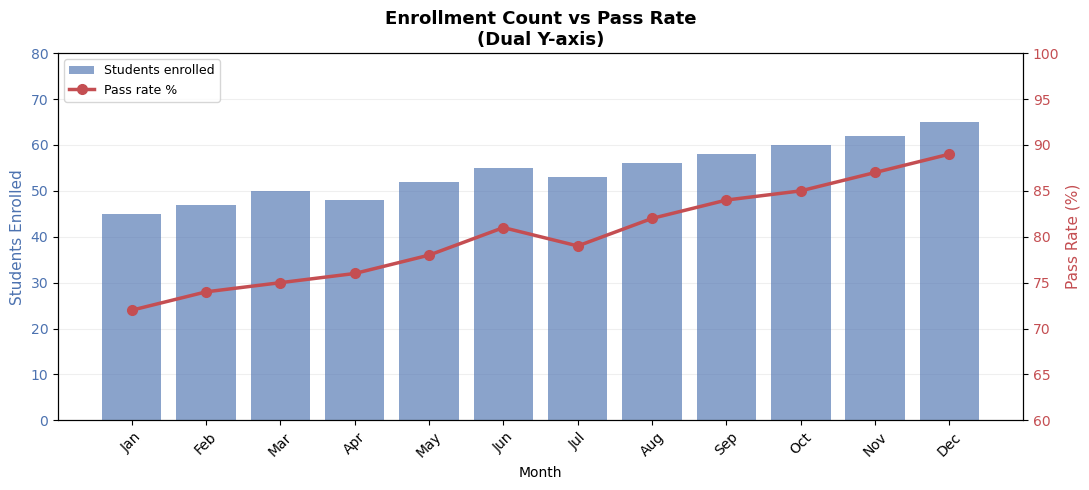

In [3]:
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.bar(months, students, color='#4C72B0', alpha=0.65, label='Students enrolled', zorder=2)
ax1.set_ylabel('Students Enrolled', color='#4C72B0', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#4C72B0')
ax1.set_ylim(0, 80)
ax1.set_xlabel('Month')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.2, zorder=1)

ax2 = ax1.twinx()
ax2.plot(months, pass_rate, color='#C44E52', lw=2.5, marker='o',
         ms=7, label='Pass rate %', zorder=3)
ax2.set_ylabel('Pass Rate (%)', color='#C44E52', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#C44E52')
ax2.set_ylim(60, 100)

lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2, loc='upper left', fontsize=9)

plt.title('Enrollment Count vs Pass Rate\n(Dual Y-axis)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Plot 2 : Bar + Two lines

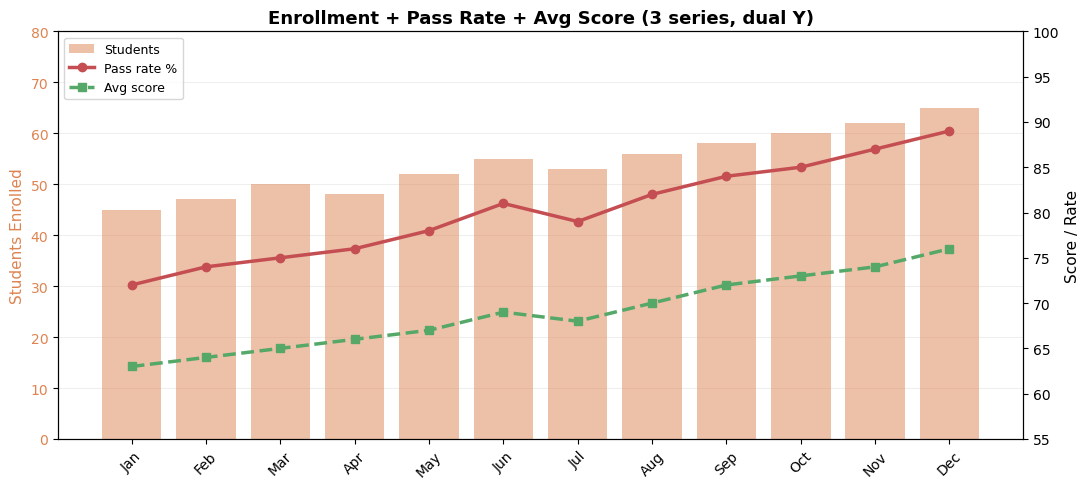

In [4]:
fig2, ax3 = plt.subplots(figsize=(11, 5))

ax3.bar(months, students, color='#DD8452', alpha=0.5, label='Students', zorder=2)
ax3.set_ylabel('Students Enrolled', color='#DD8452', fontsize=11)
ax3.tick_params(axis='y', labelcolor='#DD8452')
ax3.set_ylim(0, 80)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.2, zorder=1)

ax4 = ax3.twinx()
ax4.plot(months, pass_rate, color='#C44E52', lw=2.5, marker='o', ms=6,
         label='Pass rate %', zorder=3)
ax4.plot(months, avg_score, color='#55A868', lw=2.5, marker='s', ms=6,
         ls='--', label='Avg score', zorder=3)
ax4.set_ylabel('Score / Rate', fontsize=11)
ax4.set_ylim(55, 100)

lines3, lbl3 = ax3.get_legend_handles_labels()
lines4, lbl4 = ax4.get_legend_handles_labels()
ax3.legend(lines3 + lines4, lbl3 + lbl4, loc='upper left', fontsize=9)

plt.title('Enrollment + Pass Rate + Avg Score (3 series, dual Y)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()